<a href="https://colab.research.google.com/github/sangram-jr/Deep-Learning-Basic/blob/main/CNN/CNN_number_pred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical     # converts numeric class labels into one-hot encoded format for training classification models


In [2]:
df = pd.read_csv("mnist_train.csv")
df_test = pd.read_csv("mnist_test.csv")

In [3]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,9,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df.shape

(24076, 785)

In [5]:
df.columns

Index(['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9',
       ...
       '28x19', '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26',
       '28x27', '28x28'],
      dtype='object', length=785)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24076 entries, 0 to 24075
Columns: 785 entries, label to 28x28
dtypes: float64(753), int64(32)
memory usage: 144.2 MB


In [7]:
df.isnull().sum()

,0
label,0
1x1,0
1x2,0
1x3,0
1x4,0
...,...
28x24,1
28x25,1
28x26,1
28x27,1


In [30]:
df = df.dropna()
df_test = df_test.dropna()

#preprocess
X_train = df.drop("label", axis=1).values
y_train = df["label"].values
X_test = df_test.drop("label", axis=1).values
y_test = df_test["label"].values

In [31]:
# convert the data between 0 and 1 so that ann,cnn model learn easily
# input data contain 0-255, so divide by 255 , it gives result between 0 and 1

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0



In [32]:
#converts input data into: 28 rows × 28 columns
# -1 means -> calculate this dimension automatically(numpy part)

X_train_img = X_train.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)



In [33]:
#convert class labels into one-hot encoded vectors

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)



# perceptorn model

In [34]:
perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation="softmax")
])

In [35]:

perceptron.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])

In [36]:
history_percp = perceptron.fit(X_train_img, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_img, y_test_cat), verbose=1)


Epoch 1/5
753/753 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7518 - loss: 1.0698 - val_accuracy: 0.8539 - val_loss: 0.6636
Epoch 2/5
753/753 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8589 - loss: 0.5950 - val_accuracy: 0.8796 - val_loss: 0.5138
Epoch 3/5
753/753 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8758 - loss: 0.5000 - val_accuracy: 0.8859 - val_loss: 0.4551
Epoch 4/5
753/753 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8829 - loss: 0.4540 - val_accuracy: 0.8920 - val_loss: 0.4223
Epoch 5/5
753/753 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8890 - loss: 0.4252 - val_accuracy: 0.8957 - val_loss: 0.4003


In [37]:
acc_percp = perceptron.evaluate(X_test_img, y_test_cat, verbose=0)[1]


In [38]:
acc_percp

0.8956999778747559

# ANN

In [39]:
ann = Sequential([
    Flatten(input_shape=(28,28)), #input layer
    Dense(128, activation="relu"),#hidden layer1
    Dense(64, activation="relu"), #hidden layer1
    Dense(10, activation="softmax")#output layer1
])

In [40]:
ann.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [41]:
history_ann = ann.fit(X_train_img, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_img, y_test_cat), verbose=1)

Epoch 1/5
753/753 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8938 - loss: 0.3636 - val_accuracy: 0.9316 - val_loss: 0.2161
Epoch 2/5
753/753 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9534 - loss: 0.1531 - val_accuracy: 0.9530 - val_loss: 0.1537
Epoch 3/5
753/753 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9684 - loss: 0.1003 - val_accuracy: 0.9616 - val_loss: 0.1236
Epoch 4/5
753/753 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9779 - loss: 0.0701 - val_accuracy: 0.9675 - val_loss: 0.1043
Epoch 5/5
753/753 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9845 - loss: 0.0499 - val_accuracy: 0.9658 - val_loss: 0.1158


In [42]:
acc_ann = ann.evaluate(X_test_img, y_test_cat, verbose=0)[1]
acc_ann

0.9657999873161316

# CNN

In [43]:
#-1   → number of images (automatically calculated)
#28   → image height
#28   → image width
#1    → number of color channels, for rgb it will be 3


X_train_cnn = X_train.reshape(-1, 28, 28,1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

In [44]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)), #kernel_size means feature
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

In [45]:
cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [46]:
history_cnn = cnn.fit(X_train_cnn, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_cnn, y_test_cat), verbose=1)

Epoch 1/5
753/753 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.8984 - loss: 0.3283 - val_accuracy: 0.9737 - val_loss: 0.0827
Epoch 2/5
753/753 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.9663 - loss: 0.1127 - val_accuracy: 0.9820 - val_loss: 0.0513
Epoch 3/5
753/753 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.9742 - loss: 0.0862 - val_accuracy: 0.9857 - val_loss: 0.0467
Epoch 4/5
753/753 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step - accuracy: 0.9812 - loss: 0.0612 - val_accuracy: 0.9839 - val_loss: 0.0488
Epoch 5/5
753/753 ━━━━━━━━━━━━━━━━━━━━ 39s 34ms/step - accuracy: 0.9839 - loss: 0.0512 - val_accuracy: 0.9859 - val_loss: 0.0448


In [47]:
acc_cnn = cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)[1]
acc_cnn

0.9858999848365784

In [49]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


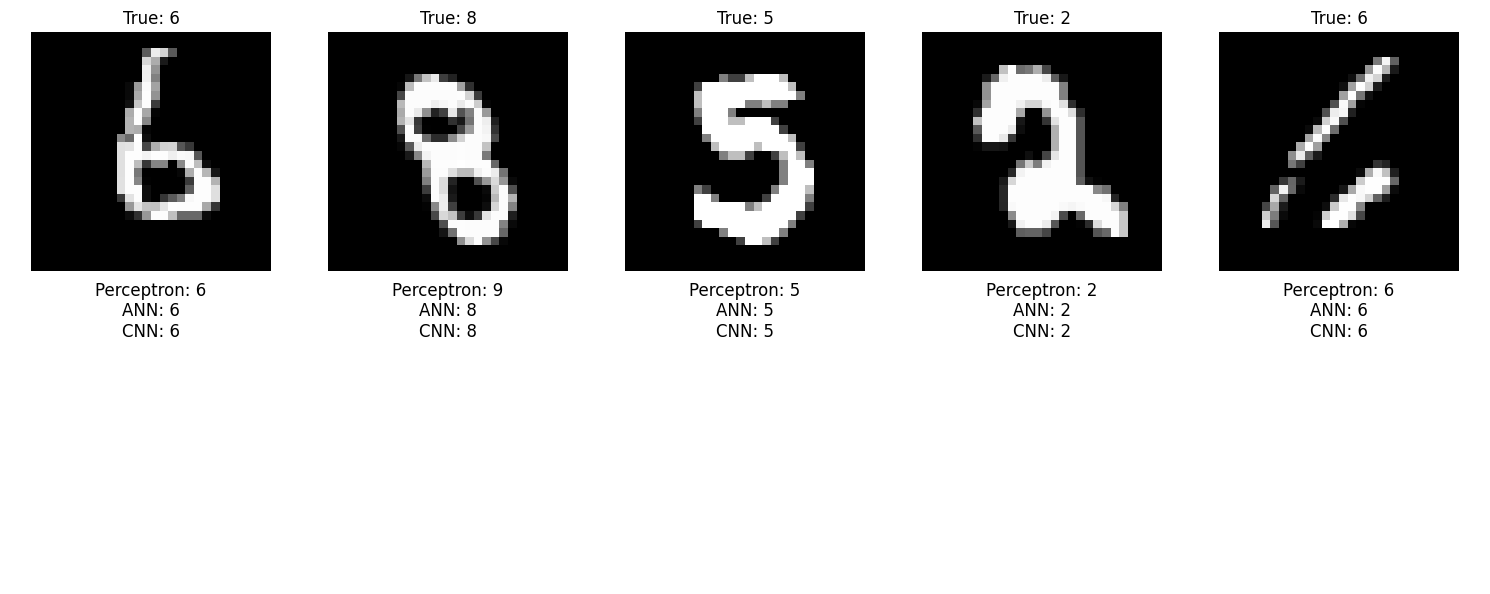

In [58]:

show_side_by_side([perceptron, ann, cnn], ["Perceptron", "ANN", "CNN"], X_test_img, X_test_cnn, y_test, 5)

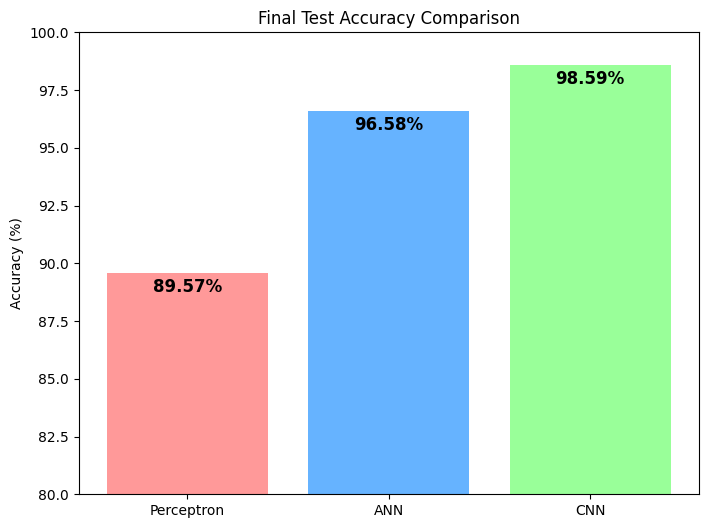

In [59]:


final_accs = [acc_percp*100, acc_ann*100, acc_cnn*100]
models = ["Perceptron", "ANN", "CNN"]

plt.figure(figsize=(8,6))
bars = plt.bar(models, final_accs, color=['#ff9999','#66b3ff','#99ff99'])
plt.title("Final Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
for bar, acc in zip(bars, final_accs):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()-1, f"{acc:.2f}%",
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.ylim(80, 100)
plt.show()

